# 1. Introduction

Dataset Olist là dữ liệu thương mại điện tử tại Brazil, bao gồm thông tin về khách hàng, đơn hàng, sản phẩm và vị trí địa lý.

Mục tiêu của bài này là thực hiện Data Understanding để hiểu cấu trúc, chất lượng và đặc điểm của dữ liệu trước khi xây dựng mô hình.

## Data Objects

Đối tượng chính trong dataset là khách hàng (customers).

Mỗi dòng dữ liệu đại diện cho một khách hàng cùng với thông tin vị trí địa lý của họ.

In [13]:
# importing the libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# 2. Data Description

## Customers Dataset
- customer_id: mã khách hàng
- customer_unique_id: mã khách hàng duy nhất
- customer_zip_code_prefix: mã zip
- customer_city: thành phố
- customer_state: bang

## Geolocation Dataset
- geolocation_zip_code_prefix: mã zip
- geolocation_lat: vĩ độ
- geolocation_lng: kinh độ
- geolocation_city: thành phố
- geolocation_state: bang

## Attributes Description

Các thuộc tính trong dữ liệu thể hiện:

- customer_id: định danh khách hàng
- customer_state: khu vực sinh sống
- latitude, longitude: vị trí địa lý

Các thuộc tính này giúp phân tích hành vi khách hàng theo khu vực và vị trí.

In [3]:
# reading the datasets
customer = pd.read_csv('./input/brazilian-ecommerce/olist_customers_dataset.csv')
geo = pd.read_csv('./input/brazilian-ecommerce/olist_geolocation_dataset.csv')
item = pd.read_csv('./input/brazilian-ecommerce/olist_order_items_dataset.csv')
payment = pd.read_csv('./input/brazilian-ecommerce/olist_order_payments_dataset.csv')
review = pd.read_csv('./input/brazilian-ecommerce/olist_order_reviews_dataset.csv')
order = pd.read_csv('./input/brazilian-ecommerce/olist_orders_dataset.csv')
product = pd.read_csv('./input/brazilian-ecommerce/olist_products_dataset.csv')
seller = pd.read_csv('./input/brazilian-ecommerce/olist_sellers_dataset.csv')
prodinfo = pd.read_csv('./input/brazilian-ecommerce/product_category_name_translation.csv')

In [17]:
# Data Size
print("Customers dataset shape:", customer.shape)
print("Geolocation dataset shape:", geo.shape)

# After join
df = customer.merge(geo, left_on="customer_zip_code_prefix", right_on="geolocation_zip_code_prefix")
print("After join shape:", df.shape)

Customers dataset shape: (99441, 5)
Geolocation dataset shape: (1000163, 5)
After join shape: (15083455, 10)


## Data Size

Customers dataset và Geolocation dataset có số lượng dòng và cột khác nhau.

Sau khi thực hiện phép join, số lượng bản ghi thay đổi do mỗi khách hàng có thể tương ứng với nhiều vị trí địa lý.

Điều này làm cho dataframe sau khi join có kích thước lớn hơn so với ban đầu.

## TASK

In [18]:
import pandas as pd

# xử lý geo (tránh duplicate zip)
geo_unique = geo.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

# merge customer + geo
customer_geo = customer.merge(
    geo_unique,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

# merge seller + geo
seller_geo = seller.merge(
    geo_unique,
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

# merge 3 bảng
df = item.merge(
    seller_geo,
    on='seller_id',
    how='left'
).merge(
    order,
    on='order_id',
    how='left'
).merge(
    customer_geo,
    on='customer_id',
    how='left'
)

print(df.head())

# Dữ liệu được kết hợp từ các bảng Customer, Seller và Geolocation thông qua các bảng trung gian Orders và Order Items.

# Bảng Geolocation được xử lý bằng cách lấy trung bình tọa độ theo zip code nhằm loại bỏ dữ liệu trùng lặp.

# Sau khi merge, bộ dữ liệu cuối cùng chứa:

# Thông tin khách hàng và người bán (thành phố, bang)
# Tọa độ địa lý (vĩ độ, kinh độ)

# Dữ liệu có thể xuất hiện trùng lặp do một khách hàng có nhiều đơn hàng hoặc một người bán bán nhiều sản phẩm. Ngoài ra, một số giá trị địa lý có thể bị thiếu do không tìm thấy zip code tương ứng.

# Bộ dữ liệu phù hợp cho việc phân tích phân bố địa lý và trực quan hóa dữ liệu.

                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value  seller_zip_code_prefix  \
0  2017-09-19 09:45:35   58.90          13.29                   27277   
1  2017-05-03 11:05:13  239.90          19.93                    3471   
2  2018-01-18 14:

In [5]:
print(df.info())
# Bộ dữ liệu gồm 46,827 dòng và 14 thuộc tính, bao gồm dữ liệu khách hàng, người bán và vị trí địa lý.

# Các kiểu dữ liệu:

# String (str): customer_id, seller_id, city, state
# Số nguyên (int64): zip_code_prefix
# Số thực (float64): latitude, longitude

# Một số thuộc tính địa lý có giá trị thiếu (~44,881/46,827), do không phải tất cả zip code đều có dữ liệu geolocation.

# Dữ liệu phù hợp cho phân tích địa lý và trực quan hóa vị trí khách hàng và người bán.

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  str    
 1   order_item_id                  112650 non-null  int64  
 2   product_id                     112650 non-null  str    
 3   seller_id                      112650 non-null  str    
 4   shipping_limit_date            112650 non-null  str    
 5   price                          112650 non-null  float64
 6   freight_value                  112650 non-null  float64
 7   seller_zip_code_prefix         112650 non-null  int64  
 8   seller_city                    112650 non-null  str    
 9   seller_state                   112650 non-null  str    
 10  geolocation_zip_code_prefix_x  112397 non-null  float64
 11  geolocation_lat_x              112397 non-null  float64
 12  geolocation_lng_x              112397 non

In [6]:
print(df.describe())
# Các thuộc tính số bao gồm zip code và tọa độ địa lý (latitude, longitude).

# Giá trị trung bình của latitude ≈ -22.93 và longitude ≈ -47.00, cho thấy dữ liệu tập trung tại khu vực Brazil.
# Độ lệch chuẩn khoảng 2.7, cho thấy dữ liệu phân bố tương đối tập trung.
# Giá trị latitude dao động từ -32.08 đến -2.50, longitude từ -67.81 đến -34.85, phản ánh phạm vi địa lý rộng.
# Zip code có giá trị trải dài từ 1021 đến 99730, cho thấy dữ liệu bao phủ nhiều khu vực khác nhau.


       order_item_id          price  freight_value  seller_zip_code_prefix  \
count  112650.000000  112650.000000  112650.000000           112650.000000   
mean        1.197834     120.653739      19.990320            24439.170431   
std         0.705124     183.633928      15.806405            27596.030909   
min         1.000000       0.850000       0.000000             1001.000000   
25%         1.000000      39.900000      13.080000             6429.000000   
50%         1.000000      74.990000      16.260000            13568.000000   
75%         1.000000     134.900000      21.150000            27930.000000   
max        21.000000    6735.000000     409.680000            99730.000000   

       geolocation_zip_code_prefix_x  geolocation_lat_x  geolocation_lng_x  \
count                  112397.000000      112397.000000      112397.000000   
mean                    24435.840191         -22.797711         -47.235518   
std                     27593.085486           2.697457        

In [7]:
print(df.isnull().sum())
# Kết quả kiểm tra cho thấy các thuộc tính liên quan đến vị trí địa lý có 1,946 giá trị thiếu, bao gồm:

# geolocation_zip_code_prefix
# geolocation_lat_customer, geolocation_lng_customer
# geolocation_lat_seller, geolocation_lng_seller

# Các thuộc tính còn lại không có giá trị thiếu.
# Nguyên nhân có thể do một số zip code không tồn tại trong bảng geolocation.

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
seller_zip_code_prefix              0
seller_city                         0
seller_state                        0
geolocation_zip_code_prefix_x     253
geolocation_lat_x                 253
geolocation_lng_x                 253
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
geolocation_zip_code_prefix_y     302
geolocation_lat_y                 302
geolocation_

In [8]:
print("Số dòng trùng:", df.duplicated().sum())

Số dòng trùng: 0


In [9]:
print(df.nunique())
# Số lượng giá trị duy nhất cho thấy mức độ đa dạng của dữ liệu:

# customer_id: 28,162 → nhiều đơn hàng cho cùng khách
# customer_unique_id: 27,193 → số lượng khách thực tế
# seller_id: 3,009 → số lượng người bán
# customer_state: 25, seller_state: 22
# → dữ liệu trải rộng trên nhiều bang
# customer_city: 614, seller_city: 592
# → độ đa dạng cao về khu vực
# Các giá trị geolocation (~2,160)
# → số lượng khu vực địa lý tương ứng với zip code

order_id                         98666
order_item_id                       21
product_id                       32951
seller_id                         3095
shipping_limit_date              93318
price                             5968
freight_value                     6999
seller_zip_code_prefix            2246
seller_city                        611
seller_state                        23
geolocation_zip_code_prefix_x     2239
geolocation_lat_x                 2239
geolocation_lng_x                 2239
customer_id                      98666
order_status                         7
order_purchase_timestamp         98112
order_approved_at                90174
order_delivered_carrier_date     81017
order_delivered_customer_date    95664
order_estimated_delivery_date      450
customer_unique_id               95420
customer_zip_code_prefix         14976
customer_city                     4110
customer_state                      27
geolocation_zip_code_prefix_y    14820
geolocation_lat_y        

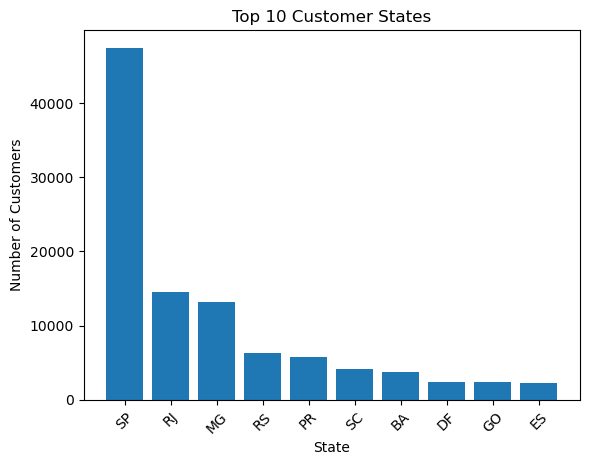

In [10]:
import matplotlib.pyplot as plt

# lấy top 10 state nhiều nhất
state_counts = df['customer_state'].value_counts().head(10)

# vẽ bar chart
plt.bar(state_counts.index, state_counts.values)

plt.title('Top 10 Customer States')
plt.xlabel('State')
plt.ylabel('Number of Customers')

plt.xticks(rotation=45)
plt.show()

# Biểu đồ thể hiện số lượng khách hàng theo từng bang (state).
# Có thể thấy bang SP có số lượng khách hàng cao nhất, vượt trội so với các bang khác.

# Các bang như MG, RJ, PR cũng có số lượng khách hàng đáng kể nhưng thấp hơn nhiều so với SP.
# Những bang còn lại có số lượng khách hàng tương đối thấp, cho thấy sự phân bố không đồng đều giữa các khu vực.

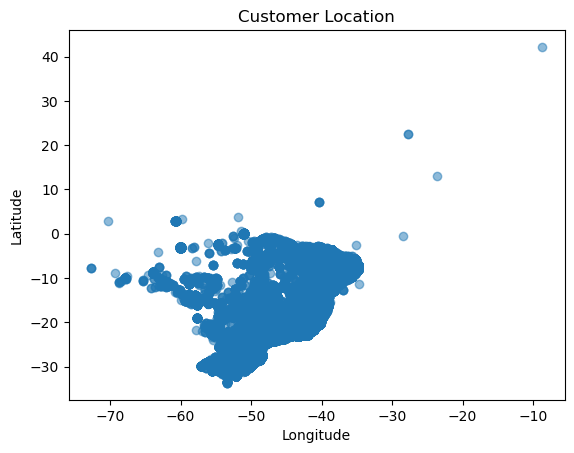

In [11]:
plt.scatter(
    df['geolocation_lng_y'],   # customer
    df['geolocation_lat_y'],
    alpha=0.5
)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Customer Location')
plt.show()

# Biểu đồ cho thấy sự phân bố địa lý của khách hàng trên toàn lãnh thổ Brazil.

# Các điểm dữ liệu tập trung dày đặc ở khu vực phía Đông Nam, đặc biệt trong khoảng kinh độ từ -50 đến -40 và vĩ độ từ -25 đến -10. Đây là khu vực có mật độ dân số cao và mức độ phát triển kinh tế lớn, cho thấy phần lớn khách hàng đến từ các đô thị lớn.

# Ngoài ra, các điểm dữ liệu rải rác trên các khu vực khác cho thấy nền tảng thương mại điện tử này có phạm vi hoạt động trên toàn quốc.

# Một số điểm nằm xa cụm chính có thể là dữ liệu ngoại lệ (outliers), có thể do sai lệch trong thông tin địa lý hoặc zip code.

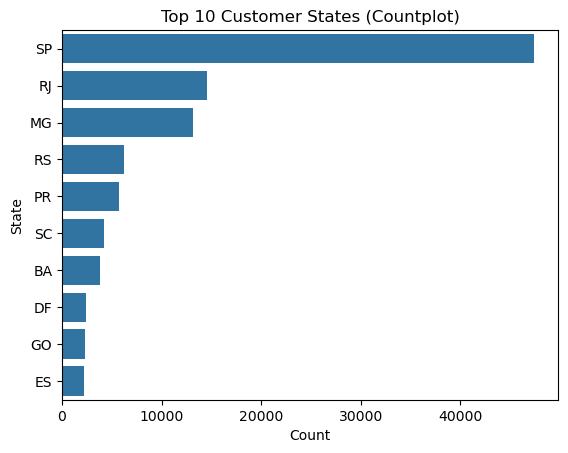

In [12]:
sns.countplot(
    y='customer_state', 
    data=df,
    order=df['customer_state'].value_counts().index[:10]
)

plt.title('Top 10 Customer States (Countplot)')
plt.xlabel('Count')
plt.ylabel('State')
plt.show()


# Biểu đồ countplot cho thấy số lượng khách hàng theo từng bang.
# Bang SP có số lượng khách hàng cao nhất, tiếp theo là MG, RJ, PR.

# Điều này cho thấy sự phân bố khách hàng không đồng đều giữa các bang, với một số khu vực tập trung đông khách hàng hơn.

## Modeling Attributes

Các thuộc tính có ý nghĩa cho modeling:
- customer_state: phân tích theo khu vực
- latitude, longitude: vị trí địa lý

Các thuộc tính không dùng:
- customer_id: chỉ là định danh, không mang ý nghĩa dự đoán

## Conclusion

Dữ liệu có chất lượng tương đối tốt, ít giá trị thiếu và không có nhiều trùng lặp.

Khách hàng phân bố không đồng đều và tập trung chủ yếu ở một số bang lớn.

Dữ liệu phù hợp cho các bài toán phân tích hành vi khách hàng theo khu vực và có thể sử dụng cho các bước modeling tiếp theo.